<a href="https://colab.research.google.com/github/ayatayoub20/Time-Series-Analysis/blob/main/Project_3_Time_Series_Analysis_Chicago_Crime.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 3 - Part 1: Chicago Crime Time Series Analysis

This project analyzes Chicago crime data using time series techniques. Each row represents one reported crime. The goal is to answer stakeholder questions using date/time features, aggregations, and visualizations.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import glob
import holidays

from matplotlib import ticker as mticks

In [3]:
files = glob.glob('/content/drive/MyDrive/Chicago_Crime_2001-2022/*.csv')

len(files)

22

In [4]:
df_list = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

df.head()

,ID,Date,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
0,1326041,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE,False,False,1624,16.0,NaN,41.957850,-87.749185
1,1319931,01/01/2001 01:00:00 PM,BATTERY,SIMPLE,RESIDENCE,False,True,825,8.0,NaN,41.783892,-87.684841
2,1324743,01/01/2001 01:00:00 PM,GAMBLING,ILLEGAL ILL LOTTERY,STREET,True,False,313,3.0,NaN,41.780412,-87.611970
3,1310717,01/01/2001 01:00:00 AM,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,2424,24.0,NaN,42.012391,-87.678032
4,1318099,01/01/2001 01:00:00 AM,BATTERY,SIMPLE,RESIDENCE PORCH/HALLWAY,False,True,214,2.0,NaN,41.819538,-87.620020


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Date                  object 
 2   Primary Type          object 
 3   Description           object 
 4   Location Description  object 
 5   Arrest                bool   
 6   Domestic              bool   
 7   Beat                  int64  
 8   District              float64
 9   Ward                  float64
 10  Latitude              float64
 11  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 603.2+ MB


In [6]:
df.columns

Index(['ID', 'Date', 'Primary Type', 'Description', 'Location Description',
       'Arrest', 'Domestic', 'Beat', 'District', 'Ward', 'Latitude',
       'Longitude'],
      dtype='object')

In [7]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Date'])

df = df.set_index('Date')

df = df.sort_index()

df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
Date,,,,,,,,,,,
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923
2001-01-01,1927872,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137
2001-01-01,4768442,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707
2001-01-01,2280620,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782
2001-01-01,9755214,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN


In [8]:
df['Year'] = df.index.year
df['Month'] = df.index.month
df['MonthName'] = df.index.month_name()

df['Hour'] = df.index.hour

df['DayOfWeek'] = df.index.day_name()

df['DayNum'] = df.index.day_of_week

In [9]:
df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude,Year,Month,MonthName,Hour,DayOfWeek,DayNum
Date,,,,,,,,,,,,,,,,,
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923,2001,1,January,0,Monday,0
2001-01-01,1927872,THEFT,AGG: FINANCIAL ID THEFT,RESIDENCE,False,False,812,8.0,NaN,41.778094,-87.770137,2001,1,January,0,Monday,0
2001-01-01,4768442,OFFENSE INVOLVING CHILDREN,SEX ASSLT OF CHILD BY FAM MBR,RESIDENCE,False,False,2124,2.0,4.0,41.807275,-87.593707,2001,1,January,0,Monday,0
2001-01-01,2280620,THEFT,FINANCIAL ID THEFT: OVER $300,RESIDENCE,False,False,915,9.0,20.0,41.806311,-87.674782,2001,1,January,0,Monday,0
2001-01-01,9755214,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN,2001,1,January,0,Monday,0


# Topic 1: Comparing Police Districts

This section analyzes which police districts had the most and least reported crimes in 2022.


In [10]:
df_2022 = df.loc['2022'].copy()

district_counts = df_2022['District'].value_counts().sort_values(ascending=False)

most_district = district_counts.idxmax()
most_count = district_counts.max()

least_district = district_counts.idxmin()
least_count = district_counts.min()

print(f"District with most crimes in 2022: {most_district} ({most_count:,} crimes)")
print(f"District with least crimes in 2022: {least_district} ({least_count:,} crimes)")

District with most crimes in 2022: 8.0 (14,805 crimes)
District with least crimes in 2022: 31.0 (15 crimes)


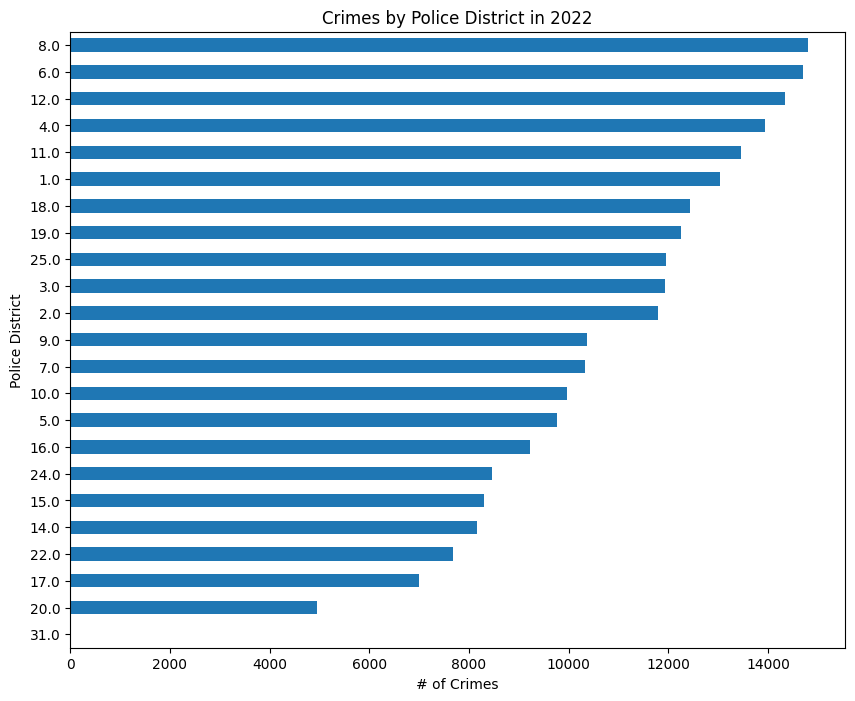

In [11]:
ax = district_counts.sort_values().plot(kind='barh', figsize=(10,8))

ax.set_title('Crimes by Police District in 2022')
ax.set_xlabel('# of Crimes')
ax.set_ylabel('Police District')

plt.show()

### Findings

- Police District **8** recorded the highest number of reported crimes in **2022**, with **14,805** incidents.
- Police District **31** recorded the lowest number of reported crimes, with only **15** incidents.
- Most districts reported between **8,000 and 15,000** crimes during 2022.

# Topic 2: Crime Trends Across the Years

This section examines whether the total number of reported crimes has increased or decreased over the years and identifies any crime types that follow a different trend.

In [12]:
year_counts = df['Year'].value_counts().sort_index()

year_counts

,count
Year,
2001,485886
2002,486807
2003,475985
2004,469422
2005,453773
2006,448179
2007,437087
2008,427183
2009,392827


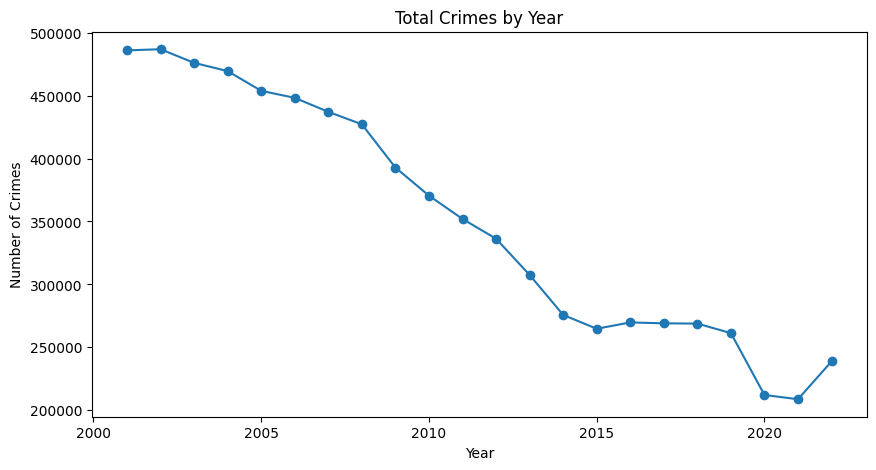

In [13]:
ax = year_counts.plot(
    marker='o',
    figsize=(10,5)
)

ax.set_title('Total Crimes by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Crimes')

plt.show()

In [14]:
crime_year = pd.crosstab(df['Year'], df['Primary Type'])

crime_year.head()

Primary Type,ARSON,ASSAULT,BATTERY,BURGLARY,CONCEALED CARRY LICENSE VIOLATION,CRIM SEXUAL ASSAULT,CRIMINAL DAMAGE,CRIMINAL SEXUAL ASSAULT,CRIMINAL TRESPASS,DECEPTIVE PRACTICE,...,OTHER OFFENSE,PROSTITUTION,PUBLIC INDECENCY,PUBLIC PEACE VIOLATION,RITUALISM,ROBBERY,SEX OFFENSE,STALKING,THEFT,WEAPONS VIOLATION
Year,,,,,,,,,,,,,,,,,,,,,
2001,1011,31384,93461,26014,1,1779,55859,29,13241,14949,...,29662,6026,9,2750,8,18441,2239,204,99277,4277
2002,1032,31523,94153,25623,0,1807,55941,27,13880,13732,...,32600,6408,8,2457,2,18523,2173,200,98332,4281
2003,955,29477,88380,25157,0,1571,55011,41,14807,13459,...,31148,6214,6,2430,2,17332,2078,247,98876,4211
2004,778,28850,87136,24564,0,1538,53164,42,15913,13255,...,29532,7476,9,2495,1,15978,1805,215,95463,4298
2005,691,27067,83964,25503,0,1521,54548,37,16655,13590,...,28028,6124,4,2730,2,16047,1817,192,85684,4106


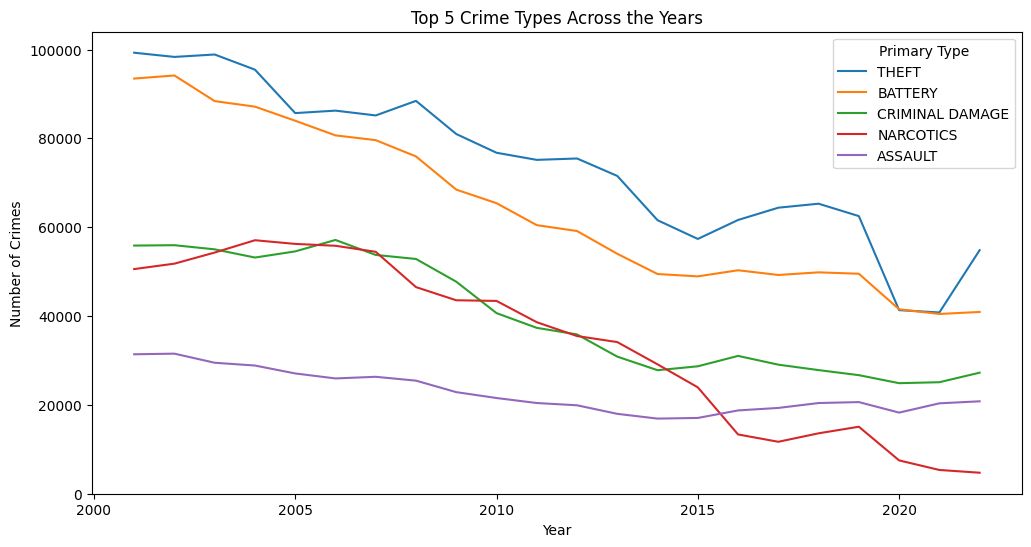

In [15]:
top5 = df['Primary Type'].value_counts().head(5).index

crime_year[top5].plot(figsize=(12,6))

plt.title('Top 5 Crime Types Across the Years')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')

plt.show()

### Findings

- The overall number of crimes generally **decreased** between 2001 and 2022.
- Although there were small fluctuations in some years, the long-term trend shows a significant decline in reported crimes.
- Most major crime types also followed a decreasing trend.
- **Narcotics** showed the most dramatic decline compared to the other crime categories, especially after 2015.

# Topic 3: Comparing AM vs PM Rush Hour

This section compares crime during AM and PM rush hours and identifies the most common crime types in each period.

In [16]:
am = df[(df['Hour'] >= 7) & (df['Hour'] <= 10)]

pm = df[(df['Hour'] >= 16) & (df['Hour'] <= 19)]

In [17]:
print("AM crimes:", len(am))
print("PM crimes:", len(pm))

AM crimes: 1097647
PM crimes: 1641051


In [18]:
top5_am = am['Primary Type'].value_counts().head(5)

top5_am

,count
Primary Type,
THEFT,260759
BATTERY,158475
CRIMINAL DAMAGE,109089
BURGLARY,96219
OTHER OFFENSE,89870


In [19]:
top5_pm = pm['Primary Type'].value_counts().head(5)

top5_pm

,count
Primary Type,
THEFT,379122
BATTERY,288003
CRIMINAL DAMAGE,183423
NARCOTICS,164754
ASSAULT,118179


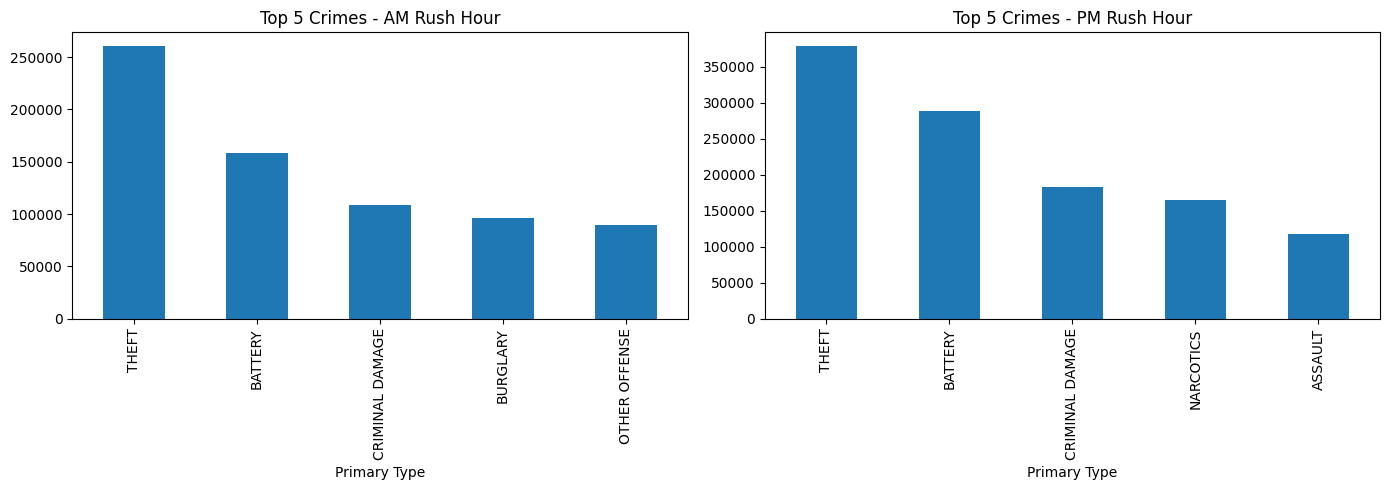

In [20]:
fig, axes = plt.subplots(1,2, figsize=(14,5))

top5_am.plot(kind='bar', ax=axes[0])

axes[0].set_title('Top 5 Crimes - AM Rush Hour')

top5_pm.plot(kind='bar', ax=axes[1])

axes[1].set_title('Top 5 Crimes - PM Rush Hour')

plt.tight_layout()

In [21]:
am_motor = am[am['Primary Type'] == 'MOTOR VEHICLE THEFT'].shape[0]

pm_motor = pm[pm['Primary Type'] == 'MOTOR VEHICLE THEFT'].shape[0]

print("AM:", am_motor)
print("PM:", pm_motor)

AM: 54035
PM: 74678


### Findings

- PM rush hour had substantially more reported crimes (**1,641,051**) than AM rush hour (**1,097,647**).
- Theft was the most common crime during both AM and PM rush hours.
- The top 5 crimes during AM rush hour were:
  1. Theft
  2. Battery
  3. Criminal Damage
  4. Burglary
  5. Other Offense
- The top 5 crimes during PM rush hour were:
  1. Theft
  2. Battery
  3. Criminal Damage
  4. Narcotics
  5. Assault
- Motor Vehicle Theft was more common during **PM rush hour (74,678)** than **AM rush hour (54,035)**.

# Conclusion

This analysis explored crime trends in Chicago using time series techniques. Three stakeholder questions were answered by comparing police districts, yearly crime trends, and rush-hour crime patterns. The analysis showed that overall crime has generally decreased over time, District 8 recorded the highest number of crimes in 2022, and PM rush hour consistently experienced more crime than AM rush hour.